# 单吸引域二维观测案例：观测升维、PySINDy 拟合与全局 Jacobian

这一版 notebook 不再沿用双吸引域图像，而是改成一个**单吸引域**的 toy system。

这样做的原因是：如果目标是讨论“通过观测函数升维，使非线性动力学在观测空间里得到全局近似”，那么单吸引域系统会更干净，也更容易明确地报告：

- 应该选择什么观测函数；
- PySINDy 在观测空间里拟合出的全局 Jacobian 矩阵是什么；
- 对应的一步残差协方差矩阵又是什么。


## 1. 系统设定

这里我们选一个只含**单个吸引域**的二维离散系统。它的原始观测仍然是 `(x1, x2)`，但更新规律故意设计成：

- `x1` 方向是稳定收缩；
- `x2` 方向除了线性衰减之外，还会受到 `x1^2` 的驱动。

因此，在原始观测空间里，系统是非线性的；但如果把观测函数选成包含 `x1^2` 的升维表示，那么动力学就可以在这个观测空间里被全局线性近似。

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / ".git").exists() or (candidate / "conftest.py").exists():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError("Could not locate repository root.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

mpl_cache = repo_root / ".tmp" / "matplotlib"
mpl_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_cache))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from exp.toy_nonlinear.nonlinear_common_mode_analysis import (
    SingleBasinConfig,
    build_observables,
    compare_observation_modes,
    compute_gis_singular_value_spectra,
    compute_two_step_svd_coarse_graining,
    project_macro_observables,
    deterministic_step_x,
    fit_global_observation_model,
    simulate_single_basin_ensemble,
    simulate_single_basin_system,
)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.unicode_minus"] = False

config = SingleBasinConfig(
    total_steps=1600,
    burn_in=200,
    seed=21,
    a=0.72,
    b=0.41,
    c=0.63,
    sigma_x1=0.03,
    sigma_x2=0.04,
    x1_0=1.1,
    x2_0=-0.7,
)
trajectory = simulate_single_basin_system(config)
ensemble = simulate_single_basin_ensemble(config, n_trajectories=8)
config


SingleBasinConfig(total_steps=1600, burn_in=200, seed=21, a=0.72, b=0.41, c=0.63, sigma_x1=0.03, sigma_x2=0.04, x1_0=1.1, x2_0=-0.7)

## 2. 原始观测空间中的相图

先只看 `(x1, x2)` 原始平面。

下面的图同时画出：

1. 确定性一步漂移方向；
2. 带噪声的样本轨迹。

这里最重要的现象是：系统虽然在二维平面里运动，但整体流向非常清楚，而且所有轨迹都被拉向同一个吸引域。这正是我们适合讨论“全局观测空间近似”的前提。

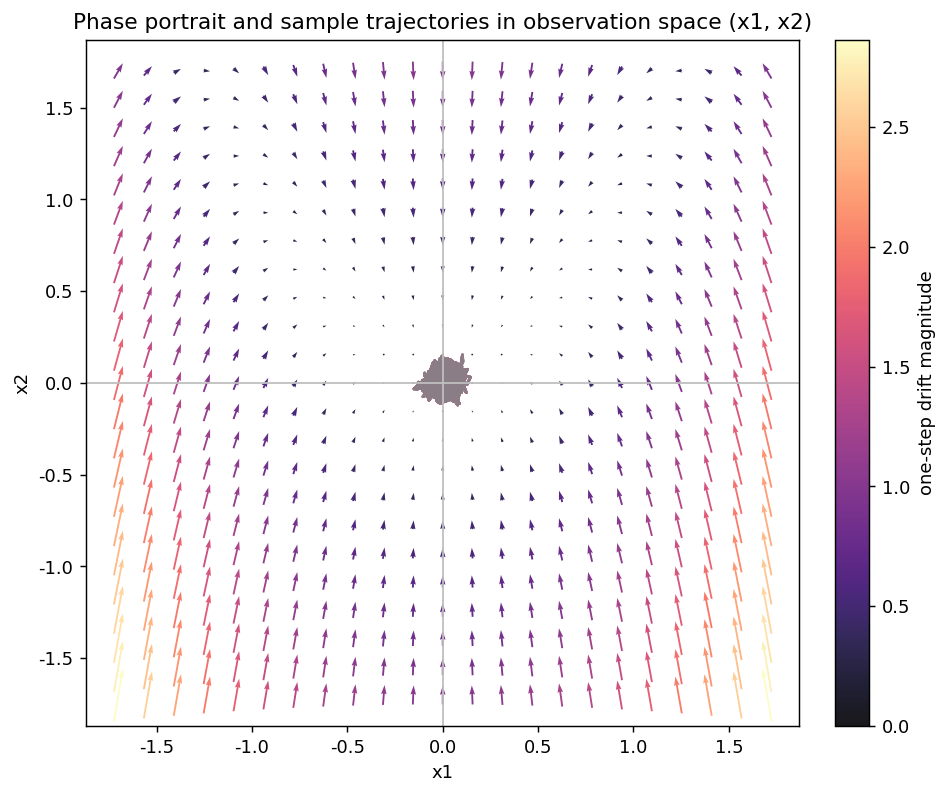

In [2]:
x = np.linspace(-1.7, 1.7, 23)
X1, X2 = np.meshgrid(x, x)
X1_next, X2_next = deterministic_step_x(X1, X2, config)
dX1 = X1_next - X1
dX2 = X2_next - X2
speed = np.sqrt(dX1**2 + dX2**2)

fig, ax = plt.subplots(figsize=(7.2, 6), constrained_layout=True)
q = ax.quiver(X1, X2, dX1, dX2, speed, cmap="magma", pivot="mid", alpha=0.9)
for sample in ensemble["trajectories"][:8]:
    ax.plot(sample[:, 0], sample[:, 1], lw=1.5, alpha=0.88)
ax.axhline(0, color="0.75", lw=1)
ax.axvline(0, color="0.75", lw=1)
ax.set_title("Phase portrait and sample trajectories in observation space (x1, x2)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
cbar = fig.colorbar(q, ax=ax)
cbar.set_label("one-step drift magnitude")
plt.show()


## 3. 观测函数怎么选

我们比较两类观测函数：

1. `g_id(x) = (x1, x2)`：直接使用原始观测；
2. `g_closure(x) = (x1, x2, x1^2)`：把 `x1^2` 加进来。

之所以优先考虑 `g_closure`，是因为这个系统里 `x2` 的更新明确受到 `x1^2` 驱动。所以如果仍然只用 `(x1, x2)`，观测空间动力学会留下系统性的非线性残差；而一旦把 `x1^2` 作为额外观测量加入，观测空间里的更新规律就会接近一个**全局线性系统**。

In [3]:
comparison = compare_observation_modes(trajectory["states"], modes=("identity", "closure"))

rows = []
for mode, result in comparison["mode_results"].items():
    rows.append(
        {
            "mode": mode,
            "dimension": result["A"].shape[0],
            "residual_mse": result["residual_mse"],
            "residual_trace": result["residual_trace"],
            "residual_trace_per_dim": result["residual_trace_per_dim"],
        }
    )
comparison_table = pd.DataFrame(rows).sort_values("residual_trace_per_dim").reset_index(drop=True)
display(comparison_table)
print(f"Selected observation mode: {comparison['selected_mode']}")


,mode,dimension,residual_mse,residual_trace,residual_trace_per_dim
0,closure,3,0.000818,0.002454,0.000818
1,identity,2,0.001228,0.002452,0.001226


Selected observation mode: closure


这里的比较逻辑不是看“总残差 trace 谁更小”，而是看**每维平均残差**。因为升维后维度变多，直接比较总量会天然偏向低维表示。

在这个例子里，`closure` 虽然多了一维，但单位维度上的残差更低，因此它才是更合适的观测函数。

## 4. 用 PySINDy 在观测空间里做全局拟合

接下来我们就在选中的 `g_closure(x) = (x1, x2, x1^2)` 上，用 PySINDy 拟合一个离散时间线性模型：

$$
\mathbf{o}_{t+1} \approx \mathbf{A}\, \mathbf{o}_t + \boldsymbol{\varepsilon}_t.
$$

这里：

- `A` 就是我们要报告的观测空间全局 Jacobian 近似；
- `\varepsilon_t` 的样本协方差就是对应的观测空间噪声协方差矩阵。

In [4]:
analysis = fit_global_observation_model(trajectory["states"], observable_mode="closure")
feature_names = analysis["feature_names"]

A_df = pd.DataFrame(analysis["A"], index=feature_names, columns=feature_names)
Sigma_df = pd.DataFrame(analysis["Sigma"], index=feature_names, columns=feature_names)

print("Discrete-time PySINDy model in closure observables:")
analysis["model"].print()
print()
print(f"Residual MSE: {analysis['residual_mse']:.6e}")
print(f"Residual trace per dim: {analysis['residual_trace_per_dim']:.6e}")
print()
display(A_df.style.format(precision=4).set_caption("Global Jacobian proxy A in observation space"))
display(Sigma_df.style.format(precision=6).set_caption("Residual covariance Sigma in observation space"))


Discrete-time PySINDy model in closure observables:
(x1)[k+1] = 0.696 x1[k] + -0.001 x2[k] + 0.401 x1^2[k]
(x2)[k+1] = 0.037 x1[k] + 0.422 x2[k] + 0.908 x1^2[k]
(x1^2)[k+1] = 0.004 x1[k] + 0.627 x1^2[k]

Residual MSE: 8.178638e-04
Residual trace per dim: 8.179158e-04



,x1,x2,x1^2
x1,0.6963,-0.0012,0.4009
x2,0.0368,0.4217,0.9077
x1^2,0.0036,0.0004,0.6267


,x1,x2,x1^2
x1,0.000884,0.000017,0.000008
x2,0.000017,0.001564,-0.000002
x1^2,0.000008,-0.000002,0.000005


这一步的关键结论是：

- 在 `g_closure` 下，PySINDy 确实给出了一个稳定、低残差的全局线性代理；
- `A` 的结构会明显体现出：`x1` 自己线性收缩，`x2` 受到 `x1^2` 驱动，而 `x1^2` 自身也按一个线性系数演化；
- `Sigma` 则把剩余噪声和未建模误差压缩成一个统一的观测空间协方差描述。

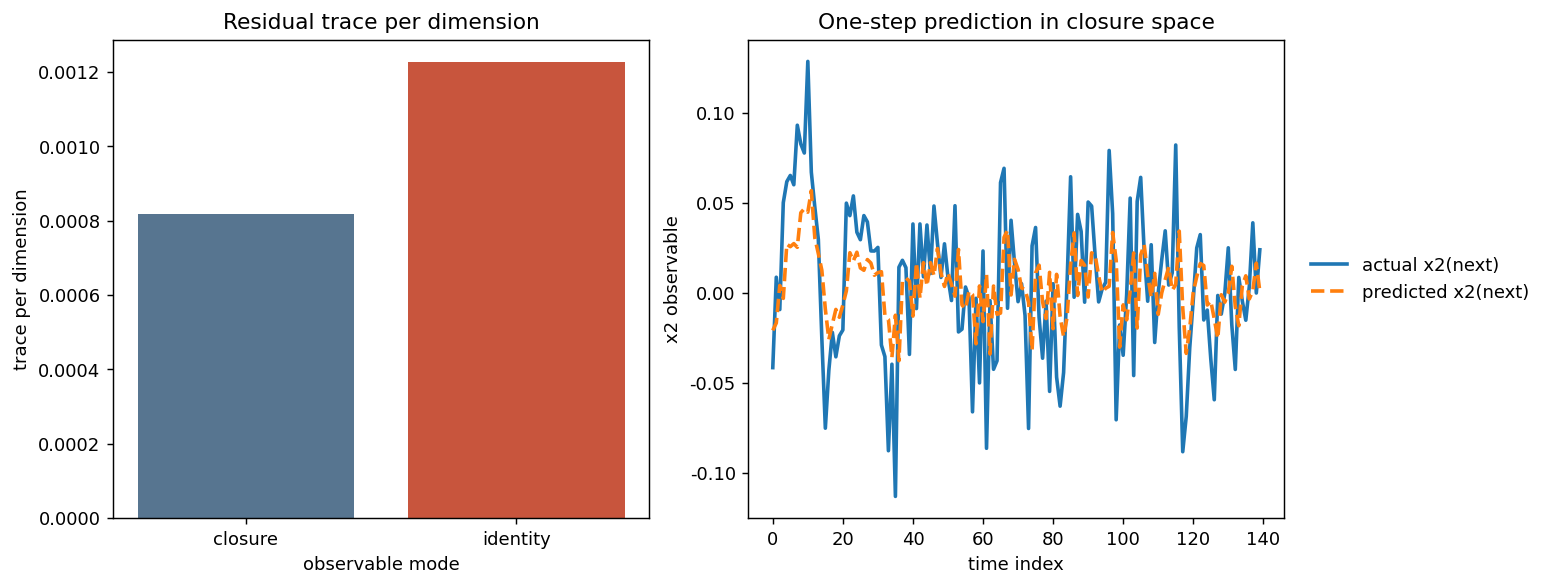

In [5]:
closure_observables, closure_names = build_observables(trajectory["states"], mode="closure")
current = closure_observables[:-1]
future = closure_observables[1:]
predicted = analysis["predicted"]

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4), constrained_layout=True)

axes[0].bar(
    comparison_table["mode"],
    comparison_table["residual_trace_per_dim"],
    color=["#577590", "#C8553D"],
)
axes[0].set_title("Residual trace per dimension")
axes[0].set_xlabel("observable mode")
axes[0].set_ylabel("trace per dimension")

window = 140
axes[1].plot(future[:window, 1], label="actual x2(next)", lw=2)
axes[1].plot(predicted[:window, 1], label="predicted x2(next)", lw=2, ls="--")
axes[1].set_title("One-step prediction in closure space")
axes[1].set_xlabel("time index")
axes[1].set_ylabel("x2 observable")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.show()


## 5. 把 `A` 和 `Sigma` 进一步拆成 `determinism / nondegeneracy` 谱

按照 [研究框架.md](/Users/yangmingzhe/Desktop/code/github/koopCE/doc/研究框架.md) 里的定义：

$$
D(\Sigma) = \log \operatorname{pdet}(\Sigma^{-1}),
\qquad
N(A, \Sigma) = \log \operatorname{pdet}(A^\top \Sigma^{-1} A).
$$

因此我们可以分别分析两组奇异值谱：

- `determinism` 谱：`Sigma^{-1}` 的奇异值谱；
- `nondegeneracy` 谱：`A^T Sigma^{-1} A` 的奇异值谱。

由于这两个矩阵在当前例子里都是对称半正定的，所以这里的奇异值也可以直接理解为其非负特征值。

In [6]:
spectra = compute_gis_singular_value_spectra(analysis["A"], analysis["Sigma"])

spectra_table = pd.DataFrame(
    {
        "index": np.arange(1, len(spectra["determinism_singular_values"]) + 1),
        "determinism_sv": spectra["determinism_singular_values"],
        "nondegeneracy_sv": spectra["nondegeneracy_singular_values"],
    }
)
display(spectra_table)
print(f"log pdet(Sigma^(-1)) = {spectra['determinism_log_pdet']:.6f}")
print(f"log pdet(A^T Sigma^(-1) A) = {spectra['nondegeneracy_log_pdet']:.6f}")


,index,determinism_sv,nondegeneracy_sv
0,1,186650.109401,73454.709180
1,2,1131.520952,550.433010
2,3,639.131382,112.025295


log pdet(Sigma^(-1)) = 25.628419
log pdet(A^T Sigma^(-1) A) = 22.233854


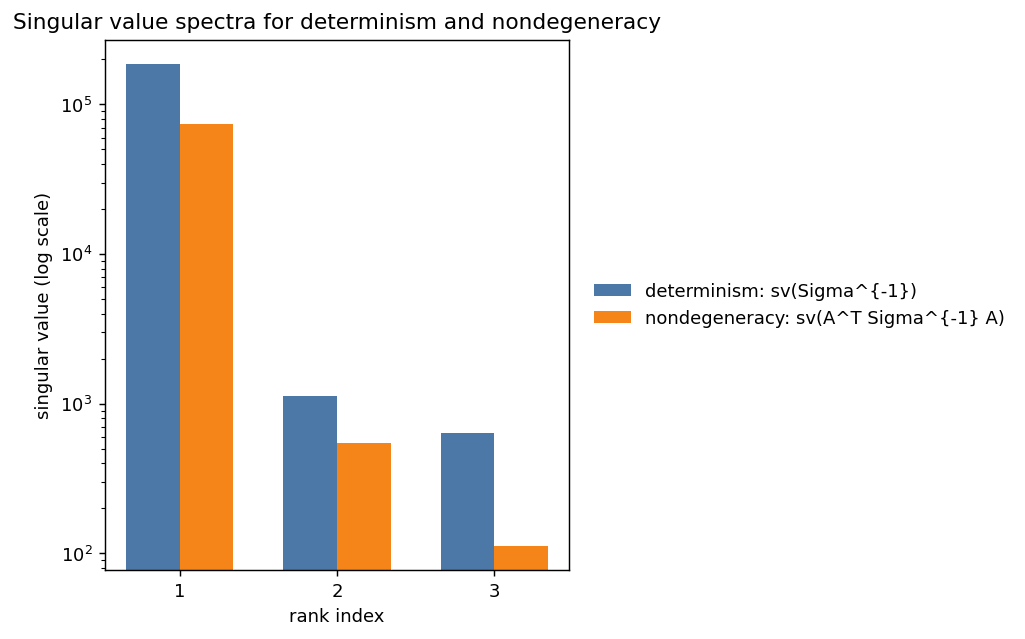

In [7]:
ranks = np.arange(1, len(spectra["determinism_singular_values"]) + 1)
bar_width = 0.34

fig, ax = plt.subplots(figsize=(7.6, 4.8), constrained_layout=True)
ax.bar(
    ranks - bar_width / 2,
    spectra["determinism_singular_values"],
    width=bar_width,
    color="#4C78A8",
    label="determinism: sv(Sigma^{-1})",
)
ax.bar(
    ranks + bar_width / 2,
    spectra["nondegeneracy_singular_values"],
    width=bar_width,
    color="#F58518",
    label="nondegeneracy: sv(A^T Sigma^{-1} A)",
)
ax.set_yscale("log")
ax.set_title("Singular value spectra for determinism and nondegeneracy")
ax.set_xlabel("rank index")
ax.set_ylabel("singular value (log scale)")
ax.set_xticks(ranks)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.show()


从这里可以把两个部分分开理解：

- `determinism` 谱完全由噪声协方差控制。奇异值越大，表示对应观测方向上的有效噪声越小，前向动力学越确定；
- `nondegeneracy` 谱则把 `A` 的可逆性结构和 `Sigma` 的噪声尺度一起考虑进去。它反映的是：在给定结果后，原因方向能否被稳定地区分开。

在这个例子里，`determinism` 谱整体高于 `nondegeneracy` 谱，说明噪声本身不算大，但经过动力学映射以后，并不是所有观测方向都同样容易被后向区分。换句话说，这个 closure 观测空间已经足够让系统看起来接近全局线性，但后向可分辨性仍然是不均匀的。

## 6. 按文献里的两步 SVD 构造粗粒化向量

补充材料 E.2.1 的做法不是直接从 `A` 或 `Sigma` 单独挑方向，而是：

1. 先分别对 `A^T Sigma^{-1} A` 和 `Sigma^{-1}` 做 SVD；
2. 把两组奇异值和对应奇异向量合并、排序；
3. 再对加权后的合并向量做第二次 SVD，得到统一的粗粒化矩阵 `W = \hat U_1^T`。

对这个 toy case，我们把它视为“已知模型”情形，采用补充材料 E.2.2 的建议：

- 第一轮直接保留 `n = 3` 个方向；
- 第二轮把宏维数固定为 `r_\epsilon = 2`。

这样做的理由是：closure 观测是三维的 `[x1, x2, x1^2]`，但它来自二维原始状态 `(x1, x2)`，所以我们希望文献算法把冗余方向压回到 2 维。


In [8]:
coarse_rank2 = compute_two_step_svd_coarse_graining(analysis["A"], analysis["Sigma"], target_rank=2)
coarse_rank1 = compute_two_step_svd_coarse_graining(analysis["A"], analysis["Sigma"], target_rank=1)

stage1_table = pd.DataFrame(
    {
        "stage1_rank": np.arange(1, coarse_rank2["effective_rank_stage1"] + 1),
        "source": [entry["source"] for entry in coarse_rank2["combined_entries"]],
        "source_index": [entry["source_index"] + 1 for entry in coarse_rank2["combined_entries"]],
        "singular_value": [entry["singular_value"] for entry in coarse_rank2["combined_entries"]],
    }
)
W_table = pd.DataFrame(coarse_rank2["W"], index=["w1", "w2"], columns=feature_names)
top_vector_table = pd.DataFrame(
    {"feature": feature_names, "weight": coarse_rank1["W"][0]}
)

display(stage1_table)
display(W_table.round(6))
display(top_vector_table.round(6))
print(f"first-stage rank = {coarse_rank2['effective_rank_stage1']}")
print(f"second-stage rank = {coarse_rank2['effective_rank_stage2']}")
print("second-stage singular values:", np.round(coarse_rank2["second_stage_singular_values"], 6))
print("top coarse-graining vector (1D):", np.round(coarse_rank1["W"][0], 6))


,stage1_rank,source,source_index,singular_value
0,1,determinism,1,186650.109401
1,2,nondegeneracy,1,73454.709180
2,3,determinism,2,1131.520952


,x1,x2,x1^2
w1,-0.008216,0.002084,0.999964
w2,-0.997425,-0.071262,-0.008047


,feature,weight
0,x1,-0.008216
1,x2,0.002084
2,x1^2,0.999964


first-stage rank = 3
second-stage rank = 2
second-stage singular values: [200582.650068   1300.389394    217.850639]
top coarse-graining vector (1D): [-0.008216  0.002084  0.999964]


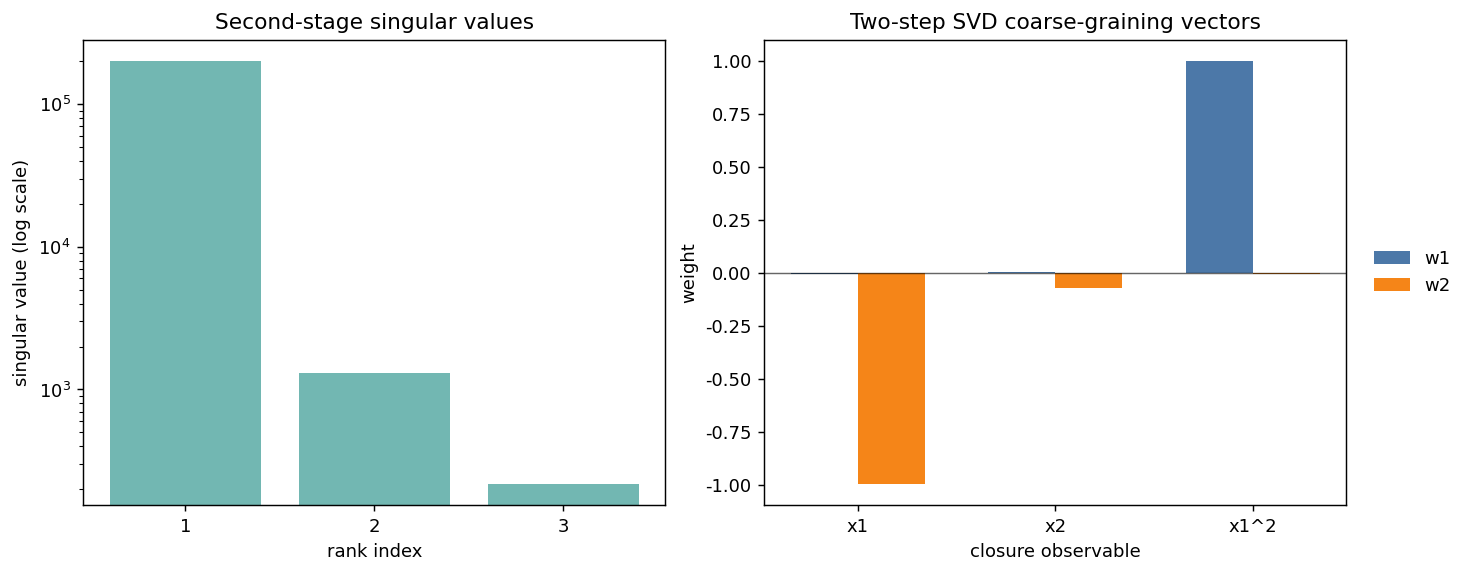

In [9]:
stage2_ranks = np.arange(1, len(coarse_rank2["second_stage_singular_values"]) + 1)
feature_positions = np.arange(len(feature_names))
bar_width = 0.34

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.3), constrained_layout=True)
axes[0].bar(stage2_ranks, coarse_rank2["second_stage_singular_values"], color="#72B7B2")
axes[0].set_yscale("log")
axes[0].set_title("Second-stage singular values")
axes[0].set_xlabel("rank index")
axes[0].set_ylabel("singular value (log scale)")
axes[0].set_xticks(stage2_ranks)

axes[1].bar(feature_positions - bar_width / 2, coarse_rank2["W"][0], width=bar_width, color="#4C78A8", label="w1")
axes[1].bar(feature_positions + bar_width / 2, coarse_rank2["W"][1], width=bar_width, color="#F58518", label="w2")
axes[1].axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
axes[1].set_title("Two-step SVD coarse-graining vectors")
axes[1].set_xlabel("closure observable")
axes[1].set_ylabel("weight")
axes[1].set_xticks(feature_positions)
axes[1].set_xticklabels(feature_names)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.show()


这里最值得注意的是：

- 第一主粗粒化向量 `w1` 几乎完全对准 `x1^2`；
- 第二主粗粒化向量 `w2` 主要对准 `x1`，只带很小的 `x2` 和 `x1^2` 修正；
- `x2` 没有进入前两条主方向。

这说明按文献里的 SVD 判据，当前 closure 观测空间里最“值得保留”的并不是几何上最直观的两个坐标，而是**最确定、最非简并、最能支撑前后向区分**的两个方向。

如果我们强行只保留 1 维宏变量，那么最强的粗粒化向量就是上面打印出来的 `w_top`，它几乎等价于只保留 `x1^2` 这个方向。这个结果也提醒我们：SVD 型粗粒化强调的是动力学信息效率，而不一定等于“最容易人类直观理解的状态坐标”。


## 7. 把宏观变量画出来看

前面的 `W` 还是矩阵语言。为了更直观地理解“为什么这种粗粒化是合理的”，下面直接把宏观变量
`(m1, m2) = W g(x)`
画出来。

我们重点看两件事：

1. 在原始 `(x1, x2)` 平面里，`m1` 和 `m2` 的等值线如何切分状态空间；
2. 把轨迹投到宏空间以后，主要动力学是否仍然清楚。


In [10]:
selected_indices = [0, 1, 2, 3]
trajectory_colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]
macro_trajectory = project_macro_observables(trajectory["states"], coarse_rank2["W"], observable_mode="closure")
macro_ensemble = np.stack(
    [
        project_macro_observables(path, coarse_rank2["W"], observable_mode="closure")
        for path in ensemble["trajectories"]
    ],
    axis=0,
)

x1_grid = np.linspace(-1.6, 1.6, 180)
x2_grid = np.linspace(-1.4, 1.4, 180)
GX1, GX2 = np.meshgrid(x1_grid, x2_grid)
grid_states = np.column_stack([GX1.ravel(), GX2.ravel()])
macro_grid = project_macro_observables(grid_states, coarse_rank2["W"], observable_mode="closure")
M1 = macro_grid[:, 0].reshape(GX1.shape)
M2 = macro_grid[:, 1].reshape(GX1.shape)

macro_summary = pd.DataFrame(
    coarse_rank2["W"], index=["m1", "m2"], columns=feature_names
)
display(macro_summary.round(6))


,x1,x2,x1^2
m1,-0.008216,0.002084,0.999964
m2,-0.997425,-0.071262,-0.008047


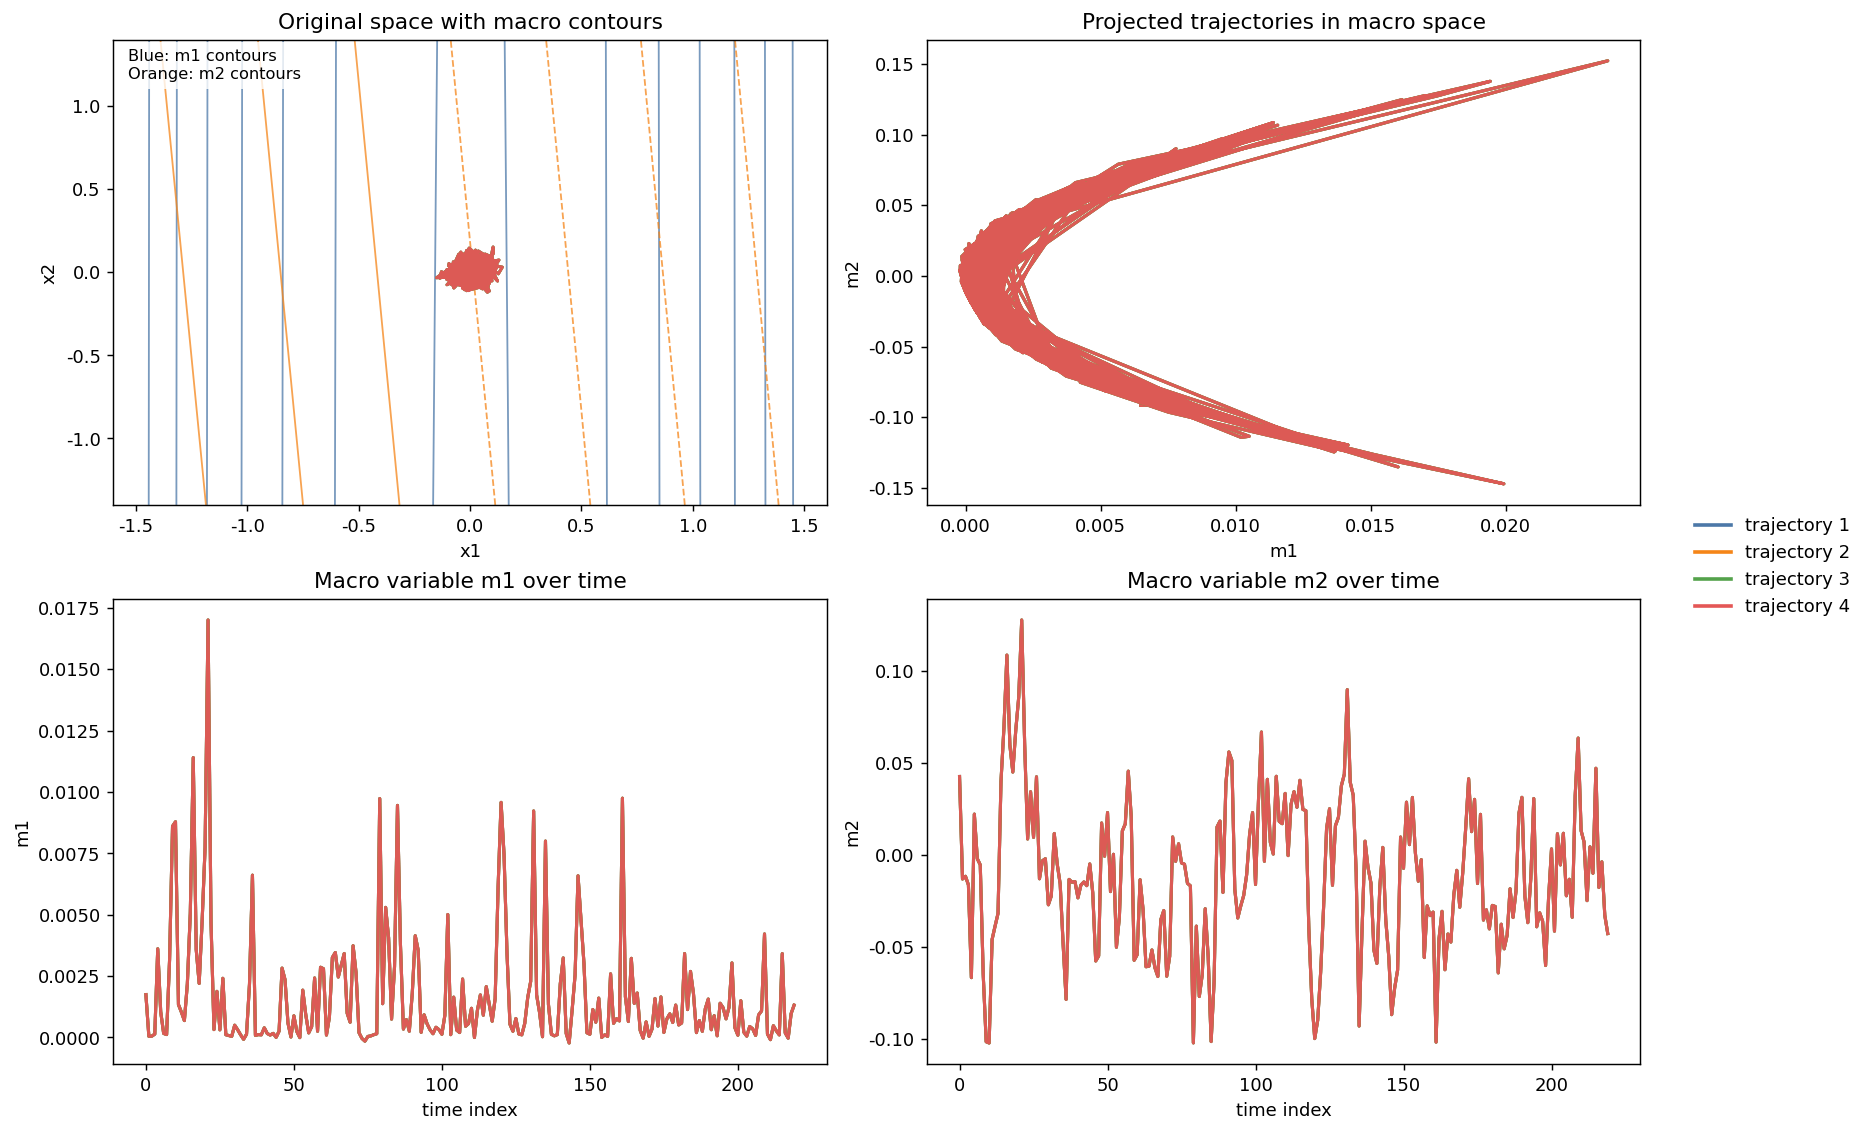

In [11]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.6), constrained_layout=True)

ax = axes[0, 0]
m1_levels = np.linspace(np.percentile(M1, 10), np.percentile(M1, 90), 7)
m2_levels = np.linspace(np.percentile(M2, 10), np.percentile(M2, 90), 7)
ax.contour(GX1, GX2, M1, levels=m1_levels, colors="#4C78A8", linewidths=1.0, alpha=0.75)
ax.contour(GX1, GX2, M2, levels=m2_levels, colors="#F58518", linewidths=1.0, alpha=0.75)
for path in ensemble["trajectories"]:
    ax.plot(path[:, 0], path[:, 1], color="#B8B8B8", linewidth=0.9, alpha=0.45)
for idx, color in zip(selected_indices, trajectory_colors):
    path = ensemble["trajectories"][idx]
    ax.plot(path[:, 0], path[:, 1], color=color, linewidth=1.6, alpha=0.95)
    ax.scatter(path[0, 0], path[0, 1], color=color, s=22, marker="o")
ax.set_title("Original space with macro contours")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.text(0.02, 0.98, "Blue: m1 contours\nOrange: m2 contours", transform=ax.transAxes, va="top", ha="left", fontsize=9, bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

ax = axes[0, 1]
for idx, color in zip(selected_indices, trajectory_colors):
    macro_path = macro_ensemble[idx]
    ax.plot(macro_path[:, 0], macro_path[:, 1], color=color, linewidth=1.7, alpha=0.95)
    ax.scatter(macro_path[0, 0], macro_path[0, 1], color=color, s=24, marker="o")
    ax.scatter(macro_path[-1, 0], macro_path[-1, 1], color=color, s=28, marker="s")
ax.set_title("Projected trajectories in macro space")
ax.set_xlabel("m1")
ax.set_ylabel("m2")

ax = axes[1, 0]
time_window = slice(0, 220)
for idx, color in zip(selected_indices, trajectory_colors):
    ax.plot(macro_ensemble[idx, time_window, 0], color=color, linewidth=1.7, alpha=0.95)
ax.set_title("Macro variable m1 over time")
ax.set_xlabel("time index")
ax.set_ylabel("m1")

ax = axes[1, 1]
for idx, color in zip(selected_indices, trajectory_colors):
    ax.plot(macro_ensemble[idx, time_window, 1], color=color, linewidth=1.7, alpha=0.95)
ax.set_title("Macro variable m2 over time")
ax.set_xlabel("time index")
ax.set_ylabel("m2")

legend_handles = [
    Line2D([0], [0], color=color, lw=2.0, label=f"trajectory {idx + 1}")
    for idx, color in zip(selected_indices, trajectory_colors)
]
fig.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.show()


这组图想传达的直觉是：

- 在原始空间里，`m1` 的等值线基本沿着 `x1^2` 的几何形状分层，`m2` 的等值线则更像沿 `x1` 方向切分；
- 所以很多在 `(x1, x2)` 上看起来不同的点，只要落在接近的 `m1, m2` 等值线组合上，就会被视为相近的宏状态；
- 把轨迹投到宏空间以后，演化主方向仍然很清楚，而且时间序列比原始微观坐标更规整。

换句话说，这里的粗粒化不是随便把维度压低，而是保留了**最能稳定描述主要动力学的方向**，把那些对长期演化贡献较弱的微观差异压进同一个宏状态里。


## 8. 小结

这个例子现在已经形成一条比较完整的方法链：

1. 先把系统改成单吸引域，避免“两个吸引域之间折中平均”的麻烦；
2. 再比较观测函数，选择能够闭合主要非线性项的 `g_closure`；
3. 再用 PySINDy 在观测空间里拟合出一个全局线性代理，直接读出 `A` 和 `Sigma`；
4. 接着把这个代理拆成 `determinism` 和 `nondegeneracy` 的奇异值谱；
5. 最后按文献里的两步 SVD，把这两个谱对应的主方向统一成粗粒化矩阵 `W`。

从这个角度看，这个 notebook 的核心信息不是“某个局部点的 Jacobian”，而是：
**通过合适的观测升维，我们不仅可以在观测空间里得到一个可解释的全局 Jacobian 近似和配套协方差矩阵，还可以继续按 SVD-based CE 的方式，把它们合成为真正用于粗粒化的宏方向。**
